# Chapter 16: Heat Exchanger Thermal Design

This notebook demonstrates shell-and-tube heat exchanger modeling using
NeqSim's `HeatExchanger` class. We size a gas-gas heat exchanger with a
specified UA value, compute the LMTD, and examine how duty and outlet
temperatures respond to changes in operating conditions.

**Key concepts:**
- UA-based heat exchanger sizing
- LMTD (Log Mean Temperature Difference) calculation
- Temperature profiles through the exchanger
- Sensitivity of duty to flow rate changes

In [1]:
# Execute against the selected, compiled NeqSim source checkout.
import os
import sys
from pathlib import Path
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import jpype

if not os.environ.get("NEQSIM_PROJECT_ROOT"):
    raise RuntimeError("Set NEQSIM_PROJECT_ROOT to the NeqSim source checkout before running.")
PROJECT_ROOT = Path(os.environ["NEQSIM_PROJECT_ROOT"]).resolve()
if not (PROJECT_ROOT / "devtools" / "neqsim_dev_setup.py").exists():
    raise RuntimeError("NEQSIM_PROJECT_ROOT must contain devtools/neqsim_dev_setup.py.")
sys.path.insert(0, str(PROJECT_ROOT / "devtools"))
from neqsim_dev_setup import neqsim_init, neqsim_classes
ns = neqsim_classes(neqsim_init(project_root=PROJECT_ROOT, recompile=False, verbose=False))
jneqsim = jpype.JPackage("neqsim")
NEQSIM_MODE = "devtools"
NOTEBOOK_PATH = Path(globals().get("__vsc_ipynb_file__", Path.cwd() / "ch14_heat_exchanger_design.ipynb")).resolve()
BOOK_ROOT = NOTEBOOK_PATH.parents[3]
FIGURES_DIR = NOTEBOOK_PATH.parent.parent / "figures"
FIGURES_DIR.mkdir(exist_ok=True)
sys.path.insert(0, str(BOOK_ROOT / "devtools"))
from book_figure_tools import configure_figures, export_figure_summary
configure_figures()
print(f"NeqSim source: {PROJECT_ROOT}; Python: {sys.executable}")

# Named NeqSim class bindings used throughout the chapter.
SystemSrkEos = jneqsim.thermo.system.SystemSrkEos
SystemPrEos = jneqsim.thermo.system.SystemPrEos
SystemSrkCPAstatoil = jneqsim.thermo.system.SystemSrkCPAstatoil
ThermodynamicOperations = jneqsim.thermodynamicoperations.ThermodynamicOperations
Stream = jneqsim.process.equipment.stream.Stream
Separator = jneqsim.process.equipment.separator.Separator
ThreePhaseSeparator = jneqsim.process.equipment.separator.ThreePhaseSeparator
Compressor = jneqsim.process.equipment.compressor.Compressor
Cooler = jneqsim.process.equipment.heatexchanger.Cooler
Heater = jneqsim.process.equipment.heatexchanger.Heater
HeatExchanger = jneqsim.process.equipment.heatexchanger.HeatExchanger
Mixer = jneqsim.process.equipment.mixer.Mixer
Splitter = jneqsim.process.equipment.splitter.Splitter
ThrottlingValve = jneqsim.process.equipment.valve.ThrottlingValve
Pump = jneqsim.process.equipment.pump.Pump
Expander = jneqsim.process.equipment.expander.Expander
Recycle = jneqsim.process.equipment.util.Recycle
ProcessSystem = jneqsim.process.processmodel.ProcessSystem


All NeqSim classes imported OK
NeqSim source: C:\Users\solbraa\OneDrive - NTNU\Documents\ChatGPT\NeqSim; Python: C:\Users\solbraa\.cache\codex-runtimes\codex-primary-runtime\dependencies\python\python.exe


## 16.1 Define Hot and Cold Streams

We model a gas-gas heat exchanger cooling hot compressed gas (hot side)
against a cooler lean gas stream (cold side).

In [2]:
# jneqsim is bound to the source JVM in the setup cell.

Stream = jneqsim.process.equipment.stream.Stream
HeatExchanger = jneqsim.process.equipment.heatexchanger.HeatExchanger
ProcessSystem = jneqsim.process.processmodel.ProcessSystem

# --- Hot side: compressed gas ---
hot_fluid = jneqsim.thermo.system.SystemSrkEos(273.15 + 120.0, 80.0)
hot_fluid.addComponent("methane", 0.85)
hot_fluid.addComponent("ethane", 0.08)
hot_fluid.addComponent("propane", 0.04)
hot_fluid.addComponent("CO2", 0.03)
hot_fluid.setMixingRule("classic")

hot_stream = Stream("Hot Gas In", hot_fluid)
hot_stream.setFlowRate(25000.0, "kg/hr")
hot_stream.setTemperature(120.0, "C")
hot_stream.setPressure(80.0, "bara")

# --- Cold side: lean gas ---
cold_fluid = jneqsim.thermo.system.SystemSrkEos(273.15 + 25.0, 70.0)
cold_fluid.addComponent("methane", 0.90)
cold_fluid.addComponent("ethane", 0.06)
cold_fluid.addComponent("propane", 0.03)
cold_fluid.addComponent("nitrogen", 0.01)
cold_fluid.setMixingRule("classic")

cold_stream = Stream("Cold Gas In", cold_fluid)
cold_stream.setFlowRate(30000.0, "kg/hr")
cold_stream.setTemperature(25.0, "C")
cold_stream.setPressure(70.0, "bara")

print("Hot side inlet:  120 °C, 80 bara, 25000 kg/hr")
print("Cold side inlet:  25 °C, 70 bara, 30000 kg/hr")

Hot side inlet:  120 °C, 80 bara, 25000 kg/hr
Cold side inlet:  25 °C, 70 bara, 30000 kg/hr


## 16.2 Configure and Run Heat Exchanger

We create a counterflow heat exchanger with a specified UA value and solve
for the outlet temperatures and duty.

In [3]:
# Create heat exchanger with two feed streams
hx = HeatExchanger("Gas-Gas HX", hot_stream, cold_stream)
hx.setUAvalue(8000.0)  # W/K
hx.setFlowArrangement("concentric tube counterflow")

# Build and run process
process = ProcessSystem()
process.add(hot_stream)
process.add(cold_stream)
process.add(hx)
process.run()

def hot_side_heat_removed_kW(exchanger):
    hot_loss = (exchanger.getInStream(0).getFluid().getEnthalpy()
                - exchanger.getOutStream(0).getFluid().getEnthalpy()) / 1000.0
    cold_gain = (exchanger.getOutStream(1).getFluid().getEnthalpy()
                 - exchanger.getInStream(1).getFluid().getEnthalpy()) / 1000.0
    assert hot_loss > 0.0 and cold_gain > 0.0, "Heat must flow from hot stream to cold stream"
    assert abs(hot_loss - cold_gain) / hot_loss < 0.001, "Exchanger energy balance does not close"
    return hot_loss

# Results
T_hot_in = hx.getInStream(0).getTemperature("C")
T_hot_out = hx.getOutStream(0).getTemperature("C")
T_cold_in = hx.getInStream(1).getTemperature("C")
T_cold_out = hx.getOutStream(1).getTemperature("C")
duty_kW = hot_side_heat_removed_kW(hx)
UA = hx.getUAvalue()
effectiveness = hx.getThermalEffectiveness()

print(f"Hot side:   {T_hot_in:.1f} °C  →  {T_hot_out:.1f} °C")
print(f"Cold side:  {T_cold_in:.1f} °C  →  {T_cold_out:.1f} °C")
print(f"Duty:       {duty_kW:.1f} kW")
print(f"UA value:   {UA:.0f} W/K")
print(f"Effectiveness: {effectiveness:.3f}")

# Calculate LMTD
dT1 = T_hot_in - T_cold_out   # hot end
dT2 = T_hot_out - T_cold_in   # cold end
if abs(dT1 - dT2) < 0.01:
    LMTD = dT1
else:
    LMTD = (dT1 - dT2) / np.log(dT1 / dT2)
print(f"LMTD:       {LMTD:.1f} °C")
print(f"Calculated Q = UA × LMTD = {UA * LMTD / 1000:.1f} kW")

Hot side:   120.0 °C  →  89.9 °C
Cold side:  25.0 °C  →  49.2 °C
Duty:       543.2 kW
UA value:   8000 W/K
Effectiveness: 0.312
LMTD:       67.8 °C
Calculated Q = UA × LMTD = 542.6 kW


## 16.3 Temperature Profile Along the Exchanger

For a counterflow exchanger with constant Cp, the temperature profiles are
approximately linear. We discretize the exchanger length and plot the
hot and cold fluid temperatures.

Figure saved: ch14_temperature_profile.png


ch14_heat_exchanger_design.ipynb:cell7:35: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


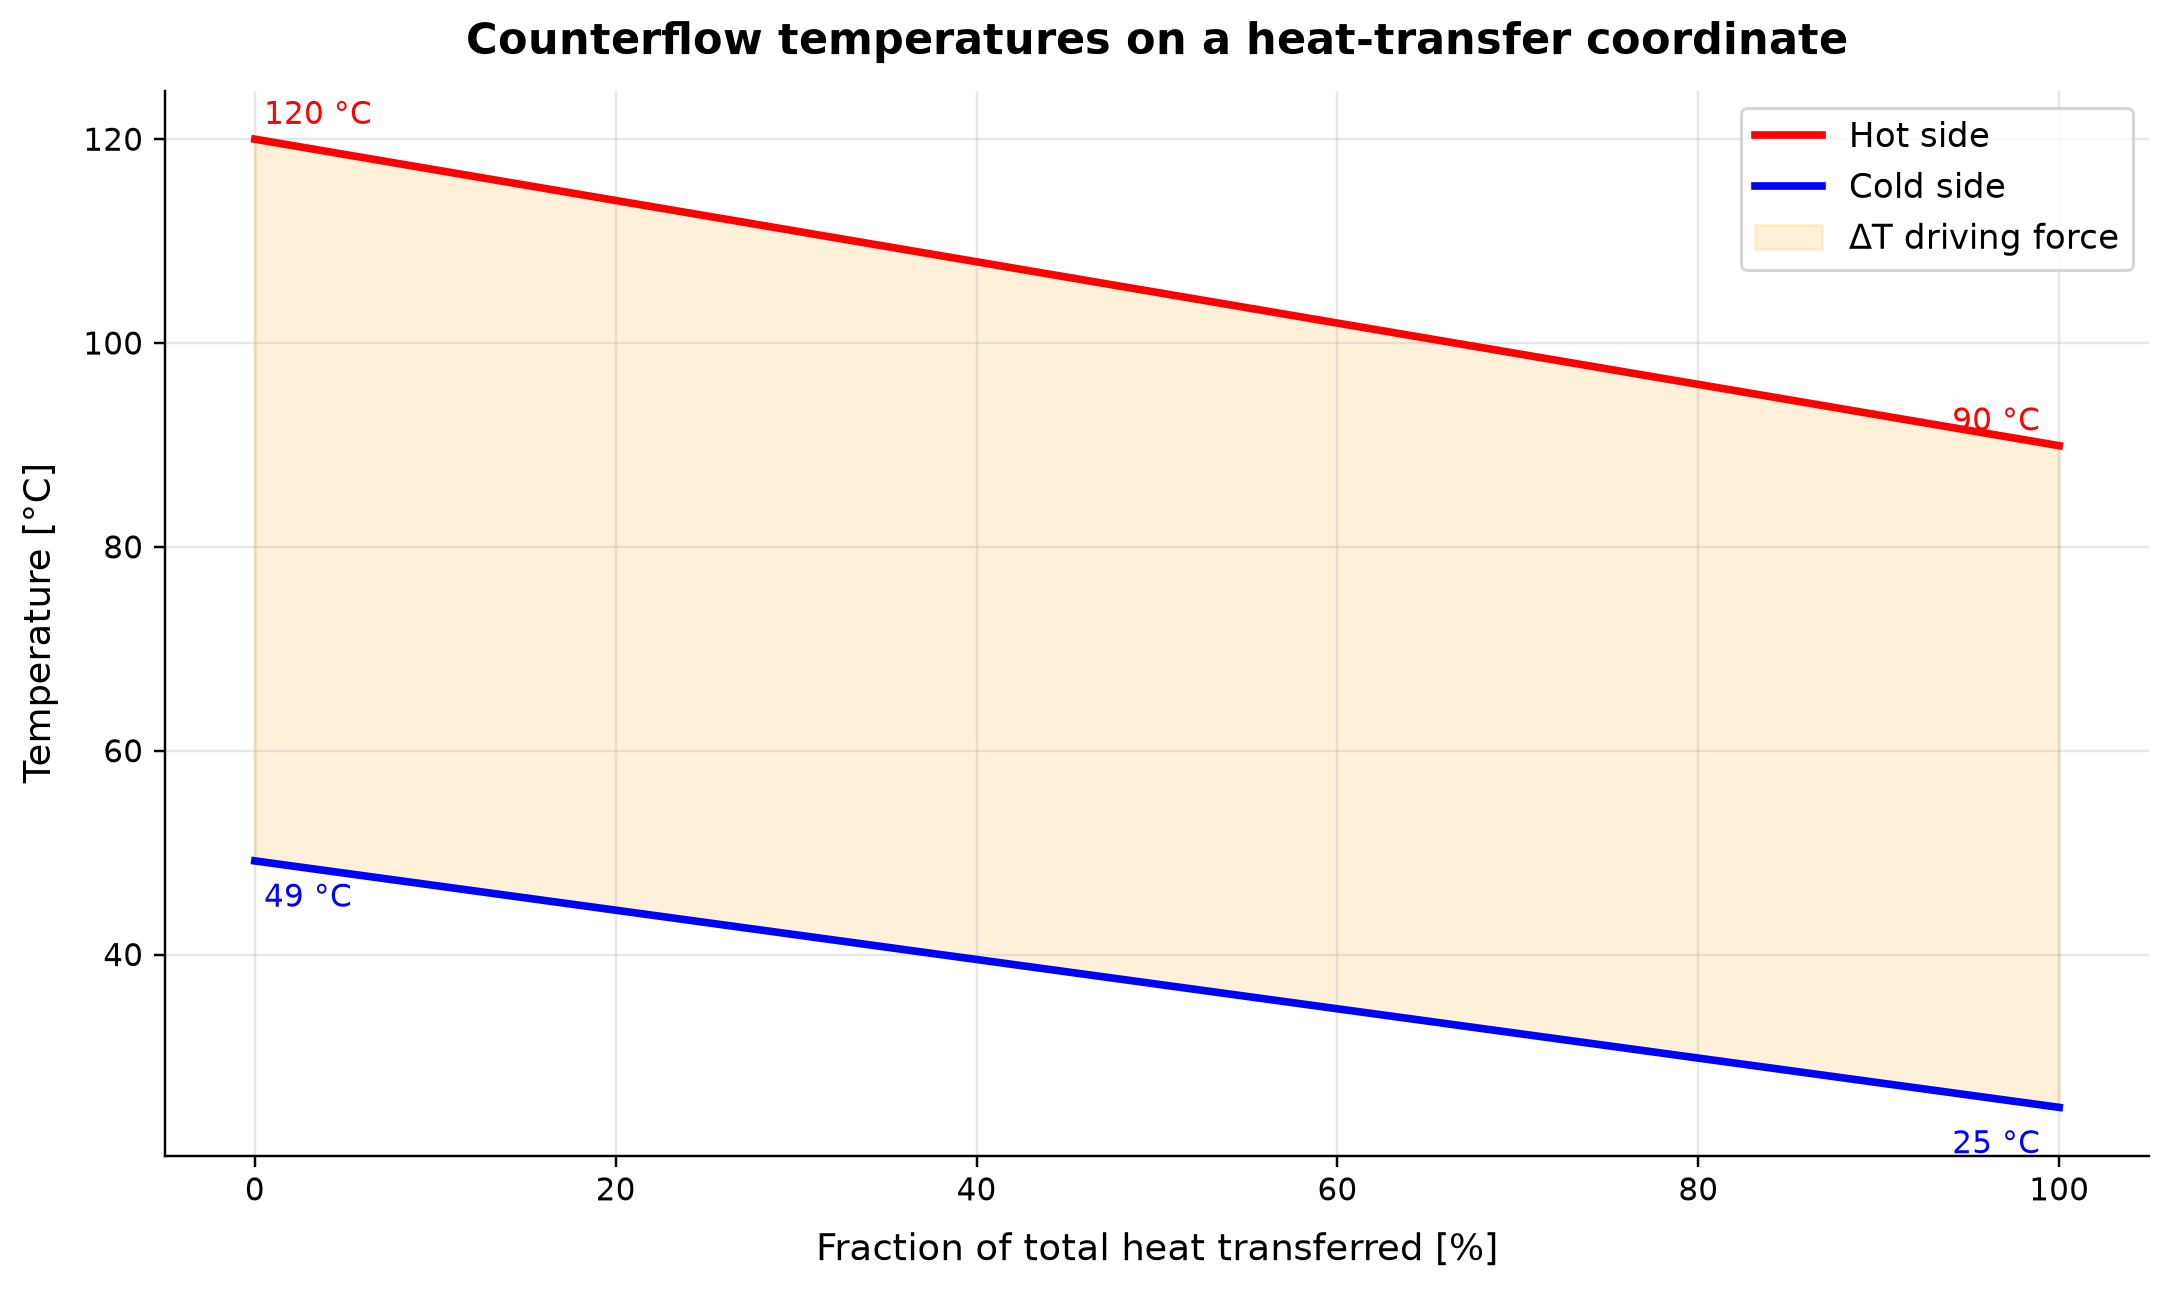

In [4]:
# Discretize along exchanger (0 = hot inlet / cold outlet end)
N = 50
x = np.linspace(0, 1, N)

# For constant Cp, temperatures vary linearly with heat transferred
T_hot_profile = T_hot_in - (T_hot_in - T_hot_out) * x
T_cold_profile = T_cold_out - (T_cold_out - T_cold_in) * x  # counterflow: cold runs opposite

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x * 100, T_hot_profile, 'r-', linewidth=2.5, label='Hot side')
ax.plot(x * 100, T_cold_profile, 'b-', linewidth=2.5, label='Cold side')

# Shade the temperature difference
ax.fill_between(x * 100, T_hot_profile, T_cold_profile, alpha=0.15, color='orange',
                label='ΔT driving force')

# Annotate ends
ax.annotate(f'{T_hot_in:.0f} °C', xy=(0, T_hot_in), fontsize=10, color='red',
            xytext=(3, 5), textcoords='offset points')
ax.annotate(f'{T_hot_out:.0f} °C', xy=(100, T_hot_out), fontsize=10, color='red',
            xytext=(-35, 5), textcoords='offset points')
ax.annotate(f'{T_cold_out:.0f} °C', xy=(0, T_cold_out), fontsize=10, color='blue',
            xytext=(3, -15), textcoords='offset points')
ax.annotate(f'{T_cold_in:.0f} °C', xy=(100, T_cold_in), fontsize=10, color='blue',
            xytext=(-35, -15), textcoords='offset points')

ax.set_xlabel('Fraction of total heat transferred [%]', fontsize=12)
ax.set_ylabel('Temperature [°C]', fontsize=12)
ax.set_title('Counterflow temperatures on a heat-transfer coordinate', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'ch14_temperature_profile.png', dpi=220, bbox_inches="tight")
plt.show()
print("Figure saved: ch14_temperature_profile.png")

**Executed-figure discussion.** Hot side: temperature spans 89.93–120 °C across the plotted cases. Cold side: temperature spans 25–49.19 °C across the plotted cases.

Counterflow transfers heat from the hot stream to the cold stream while maintaining a local temperature driving force along the exchanger. The plotted coordinate must use a consistent hot-to-cold spatial convention; an apparent temperature cross can be a plotting error or an infeasible specification. Check both terminal approaches and any internal pinch, and confirm hot-side enthalpy loss equals cold-side gain on the stated duty basis.


## 16.4 Sensitivity: Duty vs. Hot-Side Flow Rate

We vary the hot-side mass flow rate and observe how duty, hot outlet
temperature, and cold outlet temperature respond. UA is held constant.

Figure saved: ch14_duty_vs_flow.png


ch14_heat_exchanger_design.ipynb:cell9:42: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


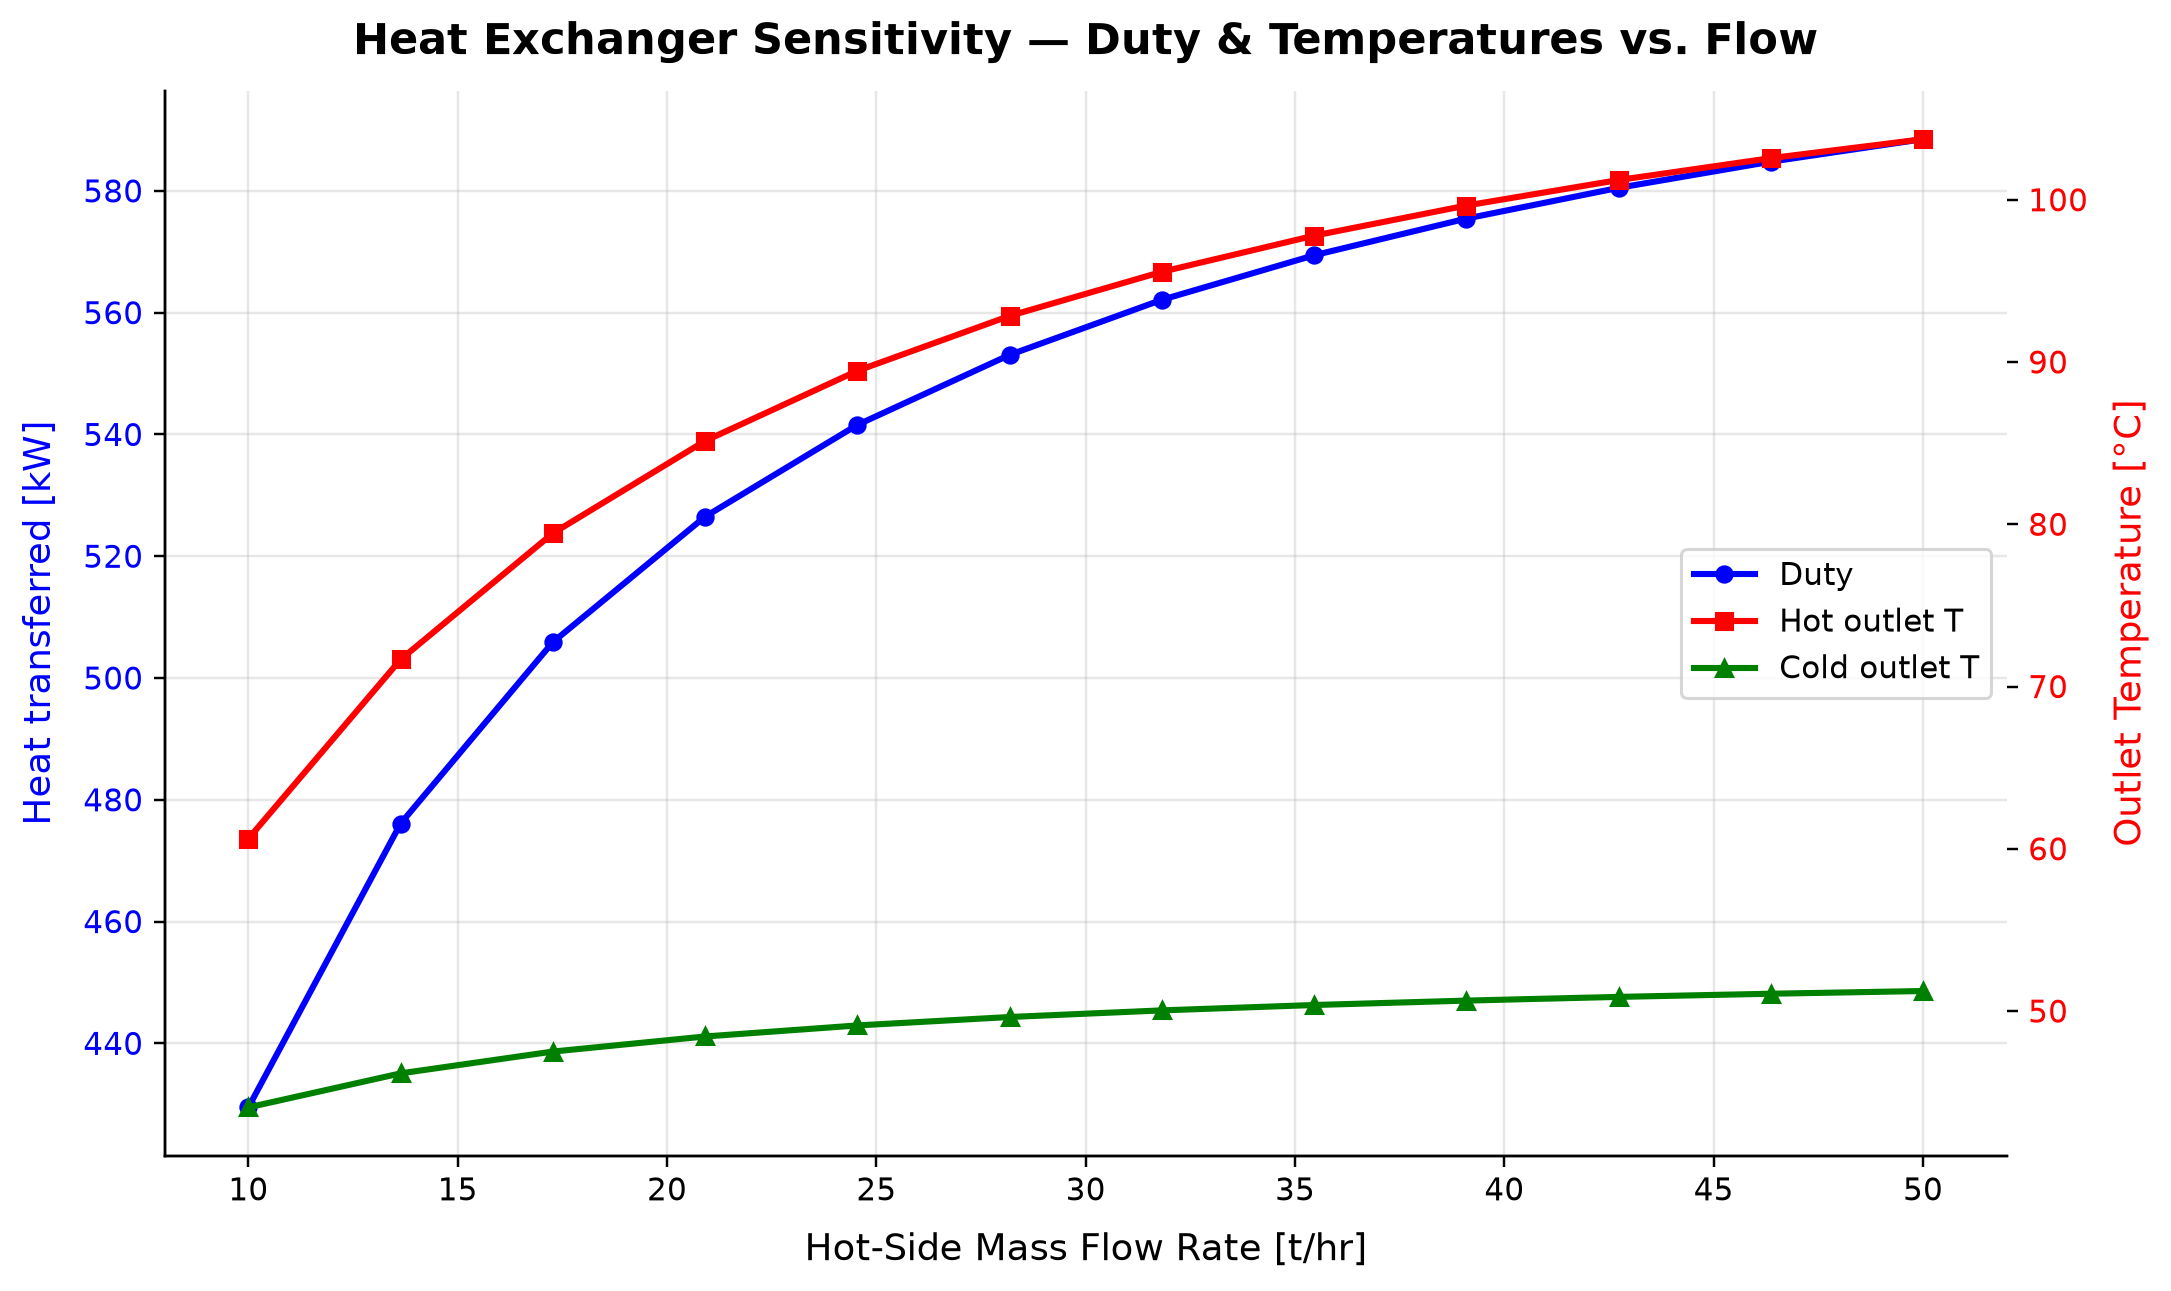

In [5]:
flow_rates = np.linspace(10000, 50000, 12)  # kg/hr
duties = []
T_hot_outs = []
T_cold_outs = []

for flow in flow_rates:
    hot_stream.setFlowRate(float(flow), "kg/hr")
    process.run()
    duties.append(hot_side_heat_removed_kW(hx))
    T_hot_outs.append(hx.getOutStream(0).getTemperature("C"))
    T_cold_outs.append(hx.getOutStream(1).getTemperature("C"))

# Reset to design
hot_stream.setFlowRate(25000.0, "kg/hr")
process.run()

fig, ax1 = plt.subplots(figsize=(10, 6))
ax2 = ax1.twinx()

line1, = ax1.plot(flow_rates / 1000, duties, 'b-o', linewidth=2, markersize=5, label='Duty')
line2, = ax2.plot(flow_rates / 1000, T_hot_outs, 'r-s', linewidth=2, markersize=5,
                  label='Hot outlet T')
line3, = ax2.plot(flow_rates / 1000, T_cold_outs, 'g-^', linewidth=2, markersize=5,
                  label='Cold outlet T')

ax1.set_xlabel('Hot-Side Mass Flow Rate [t/hr]', fontsize=12)
ax1.set_ylabel('Heat transferred [kW]', fontsize=12, color='blue')
ax2.set_ylabel('Outlet Temperature [°C]', fontsize=12, color='red')

ax1.tick_params(axis='y', labelcolor='blue')
ax2.tick_params(axis='y', labelcolor='red')

lines = [line1, line2, line3]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='center right', fontsize=10)

ax1.set_title('Heat Exchanger Sensitivity — Duty & Temperatures vs. Flow', fontsize=14)
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'ch14_duty_vs_flow.png', dpi=220, bbox_inches="tight")
plt.show()
print("Figure saved: ch14_duty_vs_flow.png")

**Executed-figure discussion.** Duty: heat transferred spans 429.5–588.5 kW across the plotted cases. Hot outlet T: outlet temperature spans 60.62–103.7 °C across the plotted cases.

Changing flow changes heat-capacity rate and residence time, so outlet temperatures and recovered duty respond together. The largest duty is not necessarily the best process result if the target outlet temperature or minimum approach is missed. Check temperature specifications and the energy balance for every flow case using newly evaluated inlet and outlet states.


## 16.5 UA Sizing Study

We vary the UA value to see how much heat transfer area is needed to
achieve different cooling duties.

Figure saved: ch14_ua_sizing.png


ch14_heat_exchanger_design.ipynb:cell11:34: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


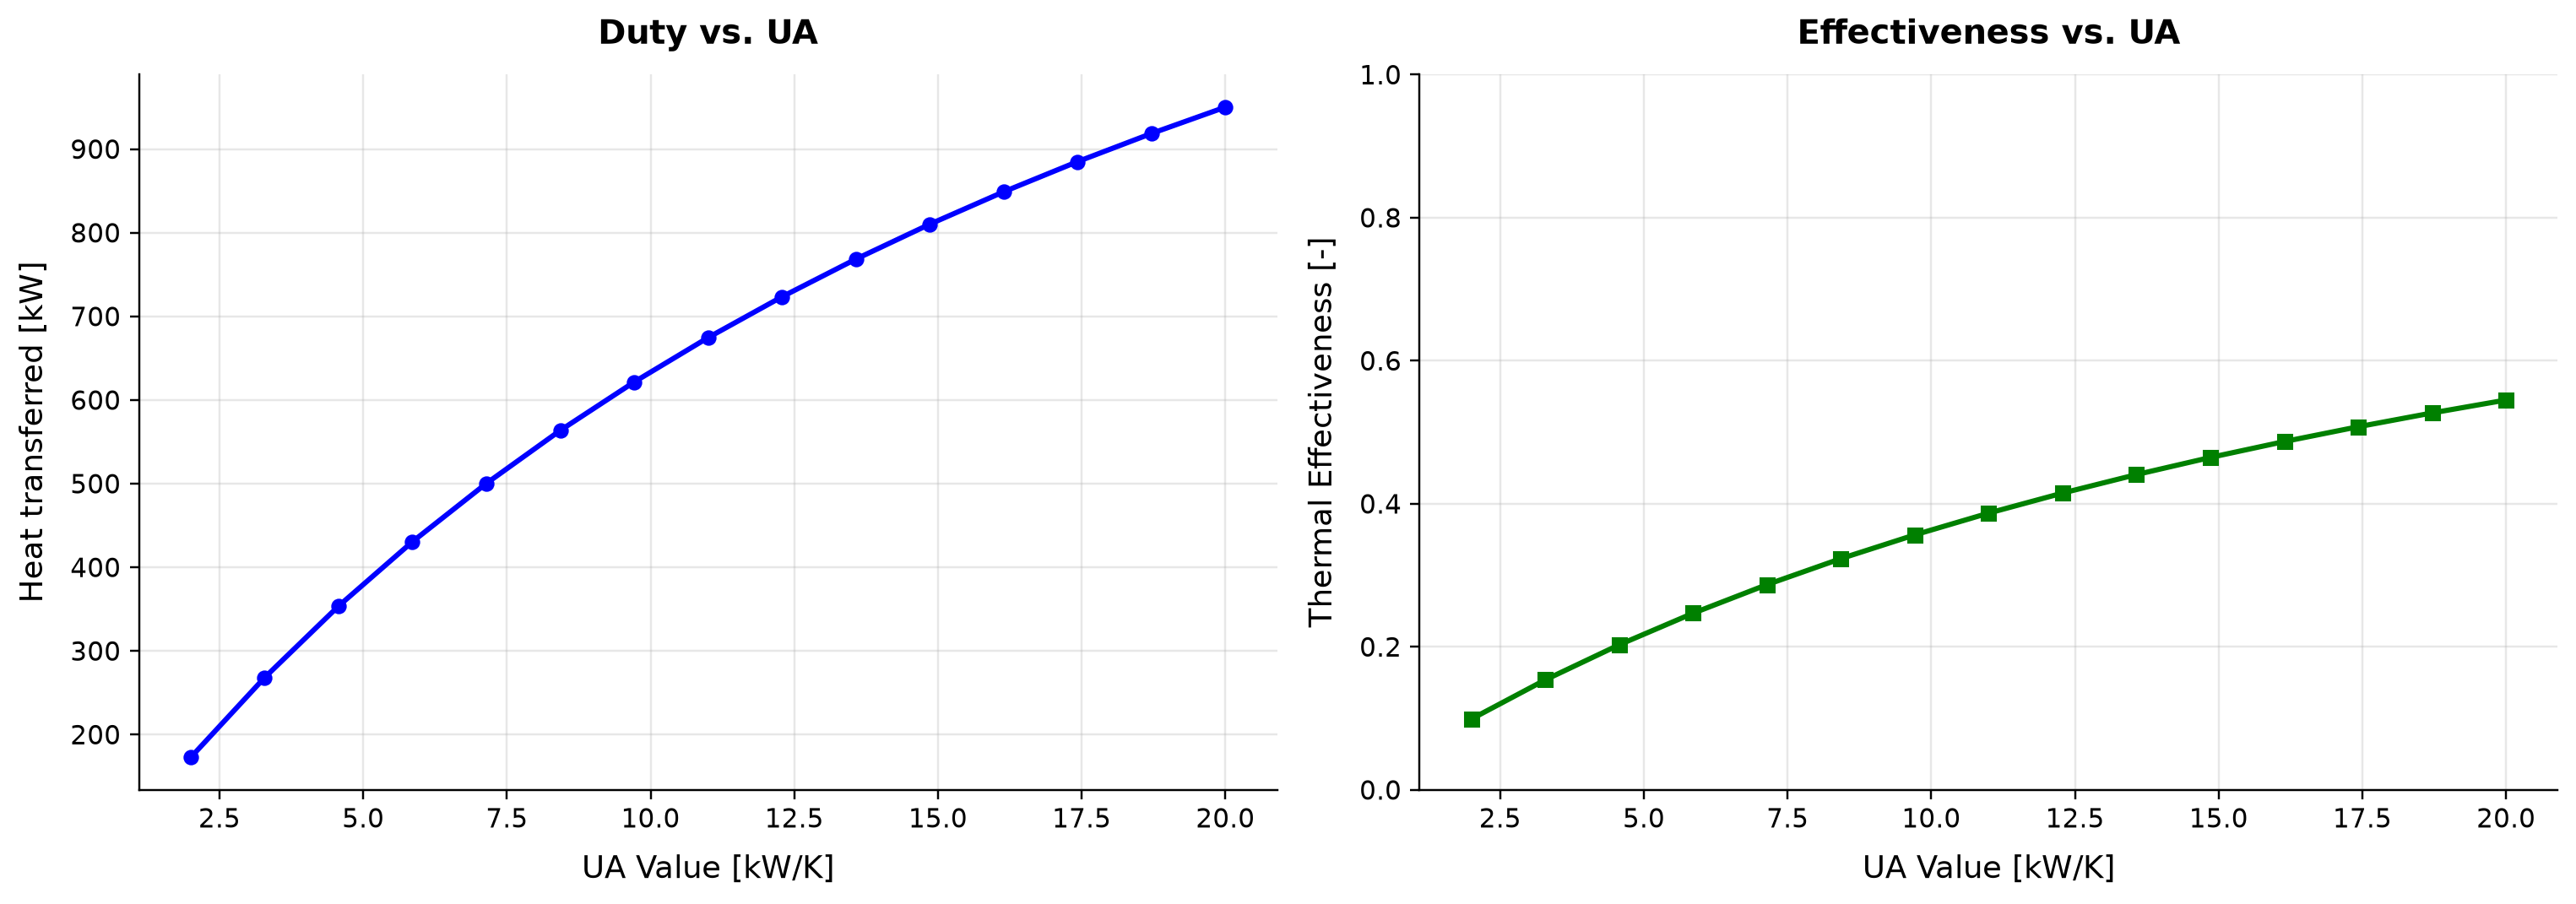

In [6]:
UA_values = np.linspace(2000, 20000, 15)
ua_duties = []
ua_T_hot_out = []
ua_effectiveness = []

for ua in UA_values:
    hx.setUAvalue(float(ua))
    process.run()
    ua_duties.append(hot_side_heat_removed_kW(hx))
    ua_T_hot_out.append(hx.getOutStream(0).getTemperature("C"))
    ua_effectiveness.append(hx.getThermalEffectiveness())

# Reset
hx.setUAvalue(8000.0)
process.run()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(UA_values / 1000, ua_duties, 'b-o', linewidth=2, markersize=5)
ax1.set_xlabel('UA Value [kW/K]', fontsize=12)
ax1.set_ylabel('Heat transferred [kW]', fontsize=12)
ax1.set_title('Duty vs. UA', fontsize=13)
ax1.grid(True, alpha=0.3)

ax2.plot(UA_values / 1000, ua_effectiveness, 'g-s', linewidth=2, markersize=5)
ax2.set_xlabel('UA Value [kW/K]', fontsize=12)
ax2.set_ylabel('Thermal Effectiveness [-]', fontsize=12)
ax2.set_title('Effectiveness vs. UA', fontsize=13)
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 1)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'ch14_ua_sizing.png', dpi=220, bbox_inches="tight")
plt.show()
print("Figure saved: ch14_ua_sizing.png")

**Executed-figure discussion.** Heat transferred spans 172.8–950.1 kW across the plotted cases. Thermal Effectiveness spans 0.09912–0.5451 across the plotted cases.

Increasing UA increases heat-transfer capability, but the streams’ heat-capacity rates and minimum approach ultimately limit recovered duty. Once the exchanger approaches its thermal limit, additional area offers progressively smaller energy benefit. Select UA using the required outlet conditions, fouling allowance, pressure-drop limits and economics rather than extrapolating duty linearly with area.


## Discussion

The heat exchanger model demonstrates the classic UA–LMTD relationship: duty
equals UA multiplied by the log-mean temperature difference. For the counterflow
arrangement, the temperature driving force is more uniform along the exchanger
length than for parallel flow, giving better thermal efficiency.

The flow sensitivity study shows that increasing the hot-side flow raises duty
(more heat to transfer) but also raises the hot outlet temperature because the
residence time decreases relative to the UA capacity. The cold outlet temperature
increases as more heat is absorbed.

The UA sizing curve exhibits diminishing returns: doubling UA does not double
duty because effectiveness approaches 1.0 asymptotically. This is critical for
economic optimization — oversizing a heat exchanger yields marginal thermal
benefit at significant additional cost.

For production optimization, heat exchangers are often constrained by:
- Minimum approach temperature (typically 5–10 °C)
- Maximum pressure drop (affects compressor power)
- Fouling allowance (reduces effective UA over time)

## Numerical output and figure provenance
The following table is extracted from the plotted numerical data. Each saved figure has an adjacent CSV and JSON record; missing points remain visible and are not replaced by interpolated results. Extrema summarize the sampled operating envelope, and are not independent validation of the model.


In [7]:
figure_results = export_figure_summary(NOTEBOOK_PATH)
print(figure_results.to_string(index=False, float_format=lambda value: f'{value:.6g}'))


                      Figure  Panel        Series             Output / unit   Minimum  Maximum  Finite points  Missing points
ch14_temperature_profile.png      1      Hot side          Temperature [°C]   89.9259      120             50               0
ch14_temperature_profile.png      1     Cold side          Temperature [°C]        25  49.1867             50               0
       ch14_duty_vs_flow.png      1          Duty     Heat transferred [kW]    429.48  588.491             12               0
       ch14_duty_vs_flow.png      2  Hot outlet T   Outlet Temperature [°C]   60.6231  103.733             12               0
       ch14_duty_vs_flow.png      2 Cold outlet T   Outlet Temperature [°C]   44.0636   51.235             12               0
          ch14_ua_sizing.png      1       Curve 1     Heat transferred [kW]   172.773  950.137             15               0
          ch14_ua_sizing.png      2       Curve 1 Thermal Effectiveness [-] 0.0991189 0.545089             15         